<a href="https://colab.research.google.com/github/Joaoplims/NLP-HandsOn/blob/main/HO03/HO03_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HO03 - Text Clustering

In [5]:
from sklearn.datasets import fetch_20newsgroups
newsgroups_train = fetch_20newsgroups(subset='train')

### 1. Analisando o dataset

In [3]:
print(f"Type of newsgroups_train: {type(newsgroups_train)}")
print(f"Keys available in the dataset: {newsgroups_train.keys()}")
print(f"Number of samples: {len(newsgroups_train.data)}")
print(f"Number of target categories: {len(newsgroups_train.target_names)}")

Type of newsgroups_train: <class 'sklearn.utils._bunch.Bunch'>
Keys available in the dataset: dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])
Number of samples: 11314
Number of target categories: 20


### 2. Analisando a distribuição das categorias

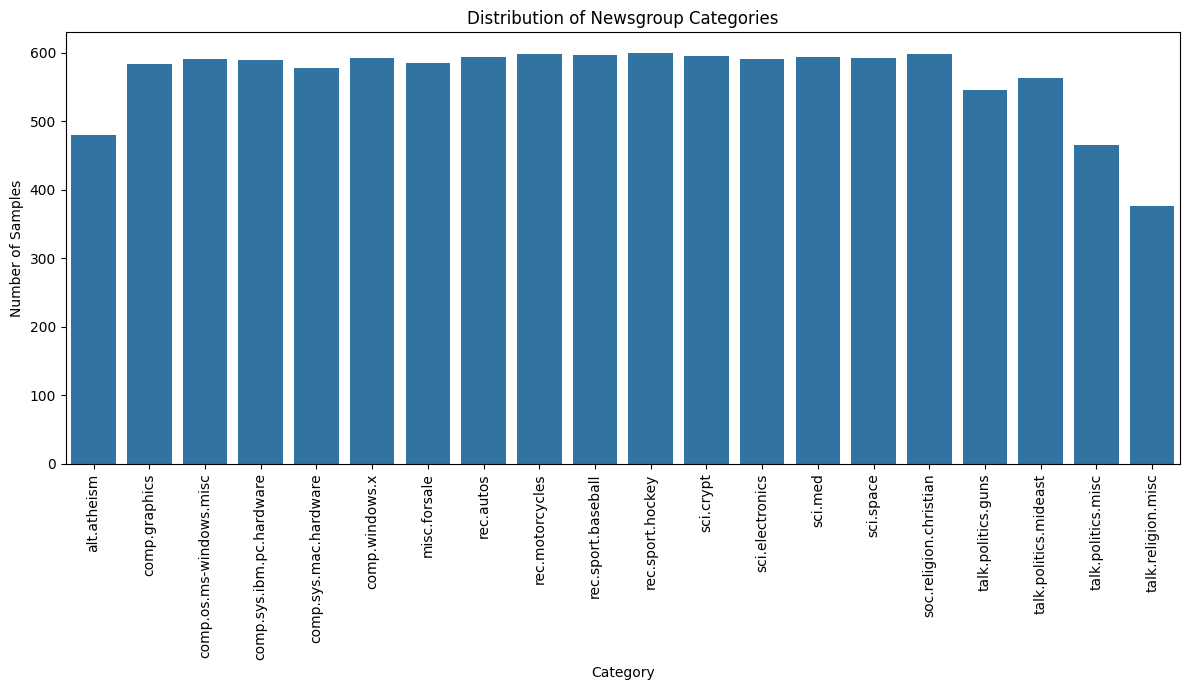

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target_counts = pd.Series(newsgroups_train.target).value_counts().sort_index()
target_names = [newsgroups_train.target_names[i] for i in target_counts.index]

plt.figure(figsize=(12, 7))
sns.barplot(x=target_names, y=target_counts.values)
plt.xticks(rotation=90)
plt.title('Distribution of Newsgroup Categories')
plt.xlabel('Category')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

### 3. Mostrando um documento de exemplo e sua categoria

In [16]:
import numpy as np

# 1. Acesso por Global Index
sample_index = 11313
print(f"--- [Global] Sample Document ({sample_index}) ---")
print(newsgroups_train.data[sample_index])
print(f"Category: {newsgroups_train.target_names[newsgroups_train.target[sample_index]]}")

print("\n" + "="*50 + "\n")

# 2. Acesso por Categoria e Index relativo
category_id = 1
relative_doc_index = 500

# Encontra os índices globais que pertencem à categoria selecionada
category_indices = np.where(newsgroups_train.target == category_id)[0]

if relative_doc_index < len(category_indices):
    global_idx = category_indices[relative_doc_index]
    print(f"--- [Category {category_id}] Document at relative index {relative_doc_index} ---")
    print(f"Category Name: {newsgroups_train.target_names[category_id]}")
    print(f"Global Index: {global_idx}")
    print("-" * 30)
    print(newsgroups_train.data[global_idx])
else:
    print(f"O índice relativo {relative_doc_index} está fora do range para esta categoria.")

--- [Global] Sample Document (11313) ---
From: gunning@cco.caltech.edu (Kevin J. Gunning)
Subject: stolen CBR900RR
Organization: California Institute of Technology, Pasadena
Lines: 12
Distribution: usa
NNTP-Posting-Host: alumni.caltech.edu
Summary: see above

Stolen from Pasadena between 4:30 and 6:30 pm on 4/15.

Blue and white Honda CBR900RR california plate KG CBR.   Serial number
JH2SC281XPM100187, engine number 2101240.

No turn signals or mirrors, lights taped over for track riders session
at Willow Springs tomorrow.  Guess I'll miss it.  :-(((

Help me find my baby!!!

kjg


Category: rec.motorcycles


--- [Category 1] Document at relative index 500 ---
Category Name: comp.graphics
Global Index: 9827
------------------------------
From: oberto@genes.icgeb.trieste.it (Jacques Oberto)
Subject: Re: HELP!!! GRASP
Organization: ICGEB
Lines: 33

CBW790S@vma.smsu.edu.Ext (Corey Webb) writes:

>In article <1993Apr19.160944.20236W@baron.edb.tih.no>
>havardn@edb.tih.no (Haavard Nesse,o92a

### *4*. Listando o nome de todas as categorias

In [17]:
print("Target category names:")
for i, name in enumerate(newsgroups_train.target_names):
    print(f"{i}: {name}")

Target category names:
0: alt.atheism
1: comp.graphics
2: comp.os.ms-windows.misc
3: comp.sys.ibm.pc.hardware
4: comp.sys.mac.hardware
5: comp.windows.x
6: misc.forsale
7: rec.autos
8: rec.motorcycles
9: rec.sport.baseball
10: rec.sport.hockey
11: sci.crypt
12: sci.electronics
13: sci.med
14: sci.space
15: soc.religion.christian
16: talk.politics.guns
17: talk.politics.mideast
18: talk.politics.misc
19: talk.religion.misc


### 6. Função de Normalização de Texto (Remoção de Pontuação)

In [6]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tag import pos_tag

# Baixa os conjuntos de dados necessários se ainda não foram baixados
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng')

# Função auxiliar para mapear as POS tags do NLTK para as tags da WordNet
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN # Padrão para substantivo se não houver tag clara

def normalize_text(text):
    """Remove pontuação, stopwords, realiza POS-tagging e lematiza uma string de texto."""
    # 1. Remover pontuação
    translator = str.maketrans('', '', string.punctuation)
    text_no_punct = text.translate(translator)

    # 2. Converter para minúsculas e tokenizar
    words = text_no_punct.lower().split()

    # 3. Remover stopwords
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in words if word not in stop_words]

    # 4. POS-tagging (Parte da Fala)
    pos_tagged_words = pos_tag(filtered_words)

    # 5. Lematização
    lemmatizer = WordNetLemmatizer()
    lemmatized_words = []
    for word, tag in pos_tagged_words:
        wntag = get_wordnet_pos(tag)
        lemmatized_words.append(lemmatizer.lemmatize(word, wntag))

    return ' '.join(lemmatized_words)

# Exemplo de uso da função
sample_text = newsgroups_train.data[0]
print(f"--- Texto original ---\n{sample_text}\n")

normalized_text_full = normalize_text(sample_text)
print(f"--- Texto normalizado (sem pontuação, stopwords, POS-tagging e lematizado) ---\n{normalized_text_full}")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


--- Texto original ---
From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----






--- Texto normalizado (sem pontuação, stopwords, POS-tagging e lematizado) ---
lerxstwamumdedu wheres thing subject car nntppostinghost rac3wamumdedu organization university maryland college park line 15 wonder anyone could enlighten car saw day 2door sp

### 7. Testando a função de normalização em outros documentos

In [19]:
# Seleciona alguns índices de documentos diferentes para testar
sample_indices = [1, 500, 1000]

for index in sample_indices:
    print(f"\n--- Documento Original ({index}) ---")
    original_text = newsgroups_train.data[index]
    print(original_text)

    print(f"\n--- Documento Normalizado ({index}) ---")
    normalized_text = normalize_text(original_text)
    print(normalized_text)
    print("="*80)


--- Documento Original (1) ---
From: guykuo@carson.u.washington.edu (Guy Kuo)
Subject: SI Clock Poll - Final Call
Summary: Final call for SI clock reports
Keywords: SI,acceleration,clock,upgrade
Article-I.D.: shelley.1qvfo9INNc3s
Organization: University of Washington
Lines: 11
NNTP-Posting-Host: carson.u.washington.edu

A fair number of brave souls who upgraded their SI clock oscillator have
shared their experiences for this poll. Please send a brief message detailing
your experiences with the procedure. Top speed attained, CPU rated speed,
add on cards and adapters, heat sinks, hour of usage per day, floppy disk
functionality with 800 and 1.4 m floppies are especially requested.

I will be summarizing in the next two days, so please add to the network
knowledge base if you have done the clock upgrade and haven't answered this
poll. Thanks.

Guy Kuo <guykuo@u.washington.edu>


--- Documento Normalizado (1) ---
guykuocarsonuwashingtonedu guy kuo subject si clock poll final call summar

### 8. Análise Estatística do Dataset Normalizado

Vamos criar uma função para contar o número de documentos e extrair o vocabulário único resultante da normalização.

In [20]:
def analyze_dataset_stats(dataset):
    """Calcula o número de documentos e a quantidade de palavras únicas após a normalização."""
    num_docs = len(dataset.data)
    unique_words = set()

    print(f"Processando {num_docs} documentos... Por favor, aguarde.")

    for doc in dataset.data:
        # Normaliza o texto
        normalized = normalize_text(doc)
        # Adiciona as palavras ao set de palavras únicas
        unique_words.update(normalized.split())

    return num_docs, len(unique_words)

# Executa a análise
total_docs, vocab_size = analyze_dataset_stats(newsgroups_train)

print(f"\n--- Estatísticas do Dataset ---")
print(f"Quantidade total de documentos: {total_docs}")
print(f"Quantidade de palavras únicas (Vocabulário): {vocab_size}")

Processando 11314 documentos... Por favor, aguarde.

--- Estatísticas do Dataset ---
Quantidade total de documentos: 11314
Quantidade de palavras únicas (Vocabulário): 130805


### 9. Construindo a representação TF-IDF manualmente

Nesta etapa, vamos transformar o texto normalizado em vetores numéricos seguindo a lógica: Matriz de Contagem (TF) e Matriz IDF.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
from scipy.sparse import csr_matrix

# 1. Preparar os dados normalizados (processando novamente para garantir consistência)
print("Normalizando documentos para a matriz...")
corpus_normalized = [normalize_text(doc) for doc in newsgroups_train.data]

# 2. Gerar a Matriz de Contagem (Counting Vectors)
# Limitamos o vocabulário para evitar estouro de memória se necessário,
# mas aqui usaremos o total identificado anteriormente.
vectorizer = CountVectorizer()
counting_matrix = vectorizer.fit_transform(corpus_normalized)

print(f"Formato da Matriz de Contagem: {counting_matrix.shape}")

Normalizando documentos para a matriz...
Formato da Matriz de Contagem: (11314, 130757)


In [8]:
# 3. Calcular o IDF
# df (document frequency) é o número de documentos que contêm o termo
df = np.diff(counting_matrix.tocsc().indptr)

# Fórmula do IDF: log(N / df) + 1 (usando a suavização padrão do sklearn)
# N é o número total de documentos
N = counting_matrix.shape[0]
idf = np.log((1 + N) / (1 + df)) + 1

print(f"Vetor IDF gerado com {len(idf)} termos.")

Vetor IDF gerado com 130757 termos.


In [9]:
# 4. Gerar a Matriz TF-IDF
# A multiplicação é elemento a elemento entre a contagem e o peso IDF de cada coluna
from sklearn.preprocessing import normalize

# Criamos uma matriz diagonal de pesos IDF para multiplicar
idf_diag = csr_matrix((idf, (np.arange(len(idf)), np.arange(len(idf)))), shape=(len(idf), len(idf)))
tfidf_matrix_manual = counting_matrix @ idf_diag

# Normalização L2 (comum no TF-IDF para que documentos longos não tenham pesos desproporcionais)
tfidf_matrix_manual = normalize(tfidf_matrix_manual, norm='l2', axis=1)

print("Matriz TF-IDF final gerada com sucesso.")
print(f"Exemplo de valores na primeira linha (primeiros 5 termos não-zero):")
first_row = tfidf_matrix_manual[0].tocoo()
for r, c, v in list(zip(first_row.row, first_row.col, first_row.data))[:5]:
    print(f"  Termo: {vectorizer.get_feature_names_out()[c]} | Peso: {v:.4f}")

Matriz TF-IDF final gerada com sucesso.
Exemplo de valores na primeira linha (primeiros 5 termos não-zero):
  Termo: lerxst | Peso: 0.2152
  Termo: neighborhood | Peso: 0.1554
  Termo: bring | Peso: 0.0965
  Termo: il | Peso: 0.1298
  Termo: thanks | Peso: 0.0675


### NOTA:
Muito provavelmente o termo **lerxst** é referente ao destinatário ou rementente do email. O fato dele ter um peso um pouco mais alto do que palavras como "**thanks**" ou "**bring**" indica que a normalização TF-IDF funcionou certinho. Mas talvez essa palavra devesse ser tratada como um ruido

### 10. Representação Word2Vec

Enquanto o TF-IDF foca na importância estatística das palavras, o Word2Vec cria embeddings densos que capturam relações semânticas entre elas. Vamos usar a biblioteca `gensim` para esta tarefa.

In [16]:
!pip install --upgrade gensim

In [19]:
from gensim.models import Word2Vec
import logging

# 1. Preparar os dados (Word2Vec espera uma lista de listas de tokens)
print("Preparando tokens para o Word2Vec...")
tokenized_corpus = [doc.split() for doc in corpus_normalized]

# 2. Treinar o modelo Word2Vec
print("Treinando o modelo Word2Vec (isso pode levar alguns instantes)...")
w2v_model = Word2Vec(sentences=tokenized_corpus,
                     vector_size=100,
                     window=5,
                     min_count=2,
                     workers=4)

print("Modelo Word2Vec treinado com sucesso!")

Preparando tokens para o Word2Vec...
Treinando o modelo Word2Vec (isso pode levar alguns instantes)...
Modelo Word2Vec treinado com sucesso!


In [20]:
# 3. Demonstrando o Word2Vec: Encontrando palavras similares
word_to_test = "image"
if word_to_test in w2v_model.wv:
    print(f"Palavras mais similares a '{word_to_test}':")
    similar_words = w2v_model.wv.most_similar(word_to_test, topn=5)
    for word, score in similar_words:
        print(f"  {word}: {score:.4f}")

# Exemplo de vetor para uma palavra
print(f"\nFormato do vetor da palavra '{word_to_test}': {w2v_model.wv[word_to_test].shape}")

Palavras mais similares a 'image':
  map: 0.8901
  display: 0.8858
  jpeg: 0.8769
  gif: 0.8765
  format: 0.8618

Formato do vetor da palavra 'image': (100,)


### 11. Função para Plotar pontos em um mapa

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.cluster as cluster
import sklearn.mixture as GMM
import time
import hdbscan
%matplotlib inline
sns.set_context('poster')
sns.set_color_codes()
plot_kwds = {'alpha' : 0.25, 's' : 80, 'linewidths':0}

Variável 'data_tfidf' criada com sucesso.
Variável 'data_word2vec' criada com sucesso.


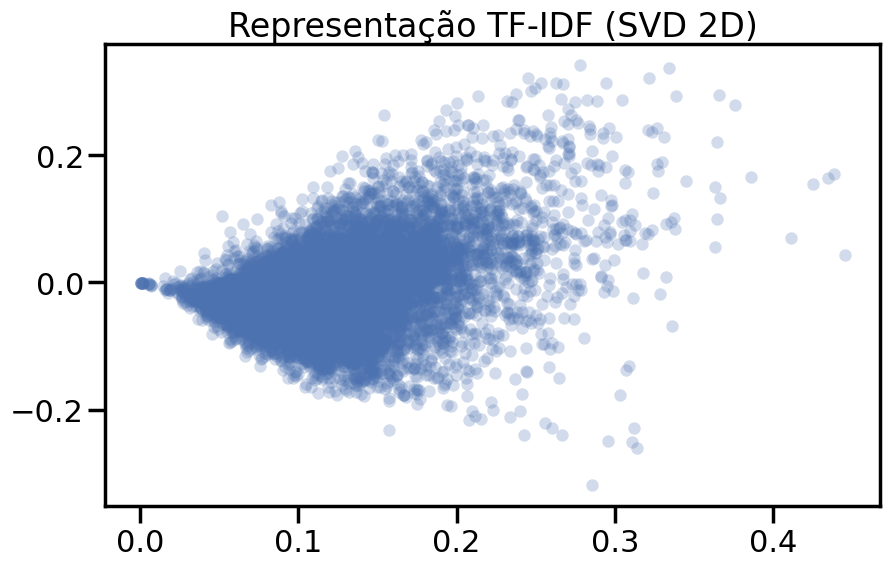

In [24]:
from sklearn.decomposition import TruncatedSVD
import numpy as np
import matplotlib.pyplot as plt

# 1. Criando representação 2D para TF-IDF
if 'tfidf_matrix_manual' in globals():
    svd = TruncatedSVD(n_components=2, random_state=42)
    data_tfidf = svd.fit_transform(tfidf_matrix_manual)
    print("Variável 'data_tfidf' criada com sucesso.")
else:
    print("Aviso: 'tfidf_matrix_manual' não encontrada. Execute as células anteriores.")

# 2. Criando representação 2D para Word2Vec
if 'w2v_model' in globals() and 'tokenized_corpus' in globals():
    # Calculando o vetor médio para cada documento
    def get_mean_vector(model, words):
        words = [w for w in words if w in model.wv]
        if len(words) >= 1:
            return np.mean(model.wv[words], axis=0)
        return np.zeros((model.vector_size,))

    w2v_vectors = np.array([get_mean_vector(w2v_model, doc) for doc in tokenized_corpus])

    # Reduzindo para 2D
    svd_w2v = TruncatedSVD(n_components=2, random_state=42)
    data_word2vec = svd_w2v.fit_transform(w2v_vectors)
    print("Variável 'data_word2vec' criada com sucesso.")
else:
    print("Aviso: Modelo Word2Vec não encontrado.")

# Plot de exemplo (TF-IDF)
if 'data_tfidf' in locals() or 'data_tfidf' in globals():
    plt.figure(figsize=(10, 6))
    plt.scatter(data_tfidf.T[0], data_tfidf.T[1], c='b', **plot_kwds)
    plt.title('Representação TF-IDF (SVD 2D)')
    plt.show()

In [44]:
def plot_clusters(data, algorithm, args, kwds, show_details=False, vector_type='tfidf'):
    """
    Executa o algoritmo, plota os resultados e opcionalmente exibe detalhes dos clusters.
    vector_type: 'tfidf' ou 'word2vec'
    """
    start_time = time.time()
    algo_instance = algorithm(*args, **kwds)
    labels = algo_instance.fit_predict(data)
    end_time = time.time()

    # Plotagem
    palette = sns.color_palette('deep', np.unique(labels).max() + 1)
    colors = [palette[x] if x >= 0 else (0.0, 0.0, 0.0) for x in labels]
    plt.scatter(data.T[0], data.T[1], c=colors, **plot_kwds)
    frame = plt.gca()
    frame.axes.get_xaxis().set_visible(False)
    frame.axes.get_yaxis().set_visible(False)
    plt.title('Clusters by {}'.format(str(algorithm.__name__)), fontsize=18)
    plt.text(-0.5, 0.6, 'Running Time {:.2f} s'.format(end_time - start_time), fontsize=14)
    plt.show()

    # Injeção da análise de detalhes
    if show_details:
        if vector_type == 'tfidf':
            show_cluster_details(data, labels, vectorizer, newsgroups_train.data)
        elif vector_type == 'word2vec':
            show_w2v_cluster_details(data, labels, w2v_model, newsgroups_train.data)

In [41]:
def show_cluster_details(data_vectors, labels, vectorizer, original_docs, n_top_words=20, n_top_docs=10):
    """
    Exibe os principais termos e documentos representativos para cada cluster.
    """
    labels = np.array(labels)
    unique_labels = np.unique(labels)
    # Filtrar ruído se necessário (ex: -1 no HDBSCAN/DBSCAN)
    unique_labels = [l for l in unique_labels if l != -1]

    feature_names = vectorizer.get_feature_names_out()

    for i in unique_labels:
        print(f"\n{'='*30}")
        print(f"  CLUSTER {i}")
        print(f"{'='*30}")

        # 1. Encontrar top tokens (média dos pesos TF-IDF no cluster)
        cluster_indices = np.where(labels == i)[0]
        cluster_tfidf = tfidf_matrix_manual[cluster_indices]
        mean_tfidf = np.asarray(cluster_tfidf.mean(axis=0)).flatten()
        top_word_indices = mean_tfidf.argsort()[::-1][:n_top_words]

        print(f"\nTop-{n_top_words} Tokens:")
        print(", ".join([feature_names[idx] for idx in top_word_indices]))

        # 2. Encontrar top documentos (amostragem ou proximidade)
        # Para simplificar, mostraremos os primeiros N documentos atribuídos ao cluster
        print(f"\nTop-{n_top_docs} Documentos (Amostras):")
        for doc_idx in cluster_indices[:n_top_docs]:
            # Mostra apenas os primeiros 150 caracteres para não poluir o output
            doc_snippet = original_docs[doc_idx].replace('\n', ' ')[:150]
            print(f" - [Doc {doc_idx}]: {doc_snippet}...")


In [42]:
def show_w2v_cluster_details(data_vectors, labels, model, original_docs, n_top_words=10, n_top_docs=10):
    """
    Exibe detalhes dos clusters usando similaridade semântica do Word2Vec.
    """
    labels = np.array(labels)
    unique_labels = [l for l in np.unique(labels) if l != -1]

    for i in unique_labels:
        print(f"\n{'='*30}\n  CLUSTER {i} (Word2Vec)\n{'='*30}")

        # 1. Top Tokens por similaridade de vetor (Semântica)
        cluster_indices = np.where(labels == i)[0]
        centroid = data_vectors[cluster_indices].mean(axis=0)

        print(f"\nPalavras semanticamente próximas ao centro do cluster:")
        try:
            closest_words = model.wv.most_similar(positive=[centroid], topn=n_top_words)
            print(", ".join([word for word, score in closest_words]))
        except:
            print("Não foi possível extrair palavras similares.")

        # 2. Amostra de Documentos
        print(f"\nTop-{n_top_docs} Documentos (Amostras):")
        for doc_idx in cluster_indices[:n_top_docs]:
            doc_snippet = original_docs[doc_idx].replace('\n', ' ')[:150]
            print(f" - [Doc {doc_idx}]: {doc_snippet}...")


### 12. Clusterização com K-Means (TF-IDF vs Word2Vec)

Vamos comparar como os documentos se agrupam usando as duas representações vetoriais diferentes.

Clusterização usando TF-IDF:


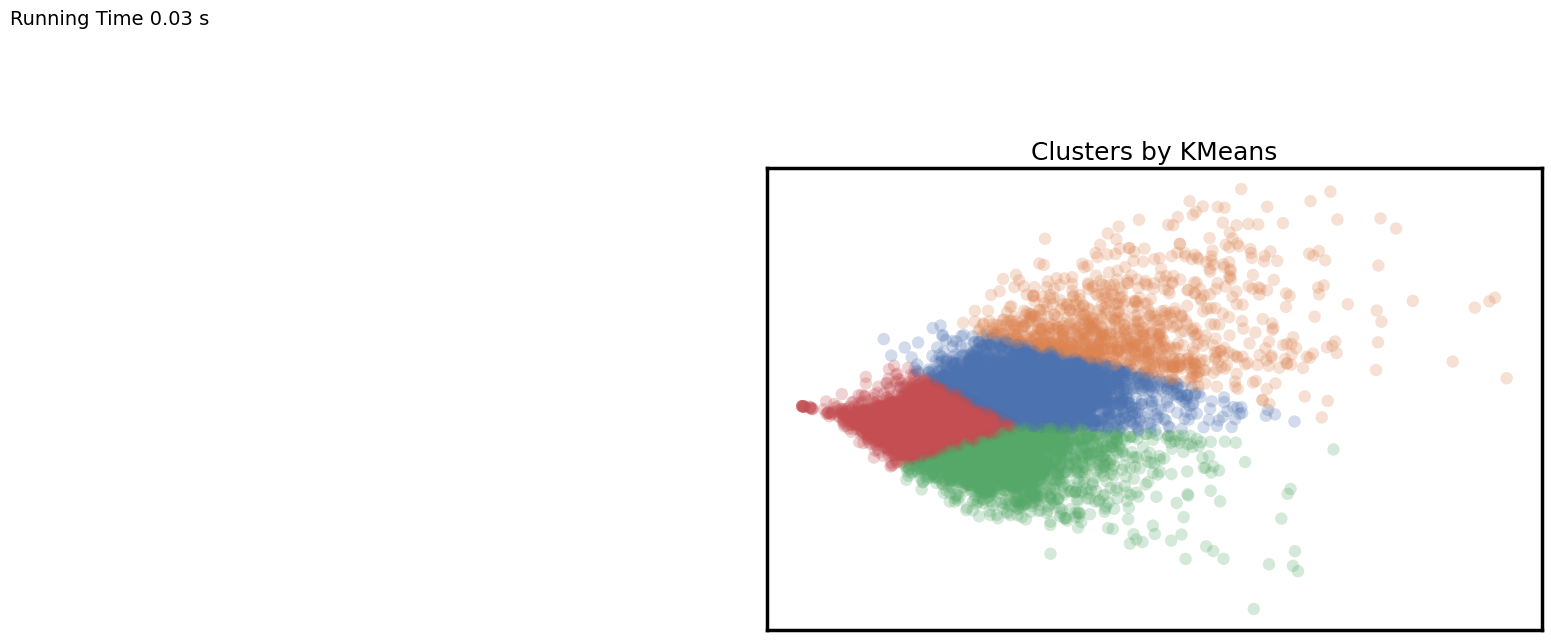


  CLUSTER 0

Top-20 Tokens:
would, write, article, one, say, people, get, go, think, dont, make, like, year, line, know, subject, organization, well, time, good

Top-10 Documentos (Amostras):
 - [Doc 5]: From: dfo@vttoulu.tko.vtt.fi (Foxvog Douglas) Subject: Re: Rewording the Second Amendment (ideas) Organization: VTT Lines: 58  In article <1r1eu1$4t@t...
 - [Doc 15]: From: mathew <mathew@mantis.co.uk> Subject: Re: <Political Atheists? Organization: Mantis Consultants, Cambridge. UK. X-Newsreader: rusnews v1.01 Line...
 - [Doc 17]: From: CPKJP@vm.cc.latech.edu (Kevin Parker) Subject: Insurance Rates on Performance Cars SUMMARY Organization: Louisiana Tech University Lines: 244 NN...
 - [Doc 20]: From: keith@cco.caltech.edu (Keith Allan Schneider) Subject: Re: <<Pompous ass Organization: California Institute of Technology, Pasadena Lines: 16 NN...
 - [Doc 33]: From: ayr1@cunixa.cc.columbia.edu (Amir Y Rosenblatt) Subject: Re: Israeli Expansion-lust Nntp-Posting-Host: cunixa.cc.columbia

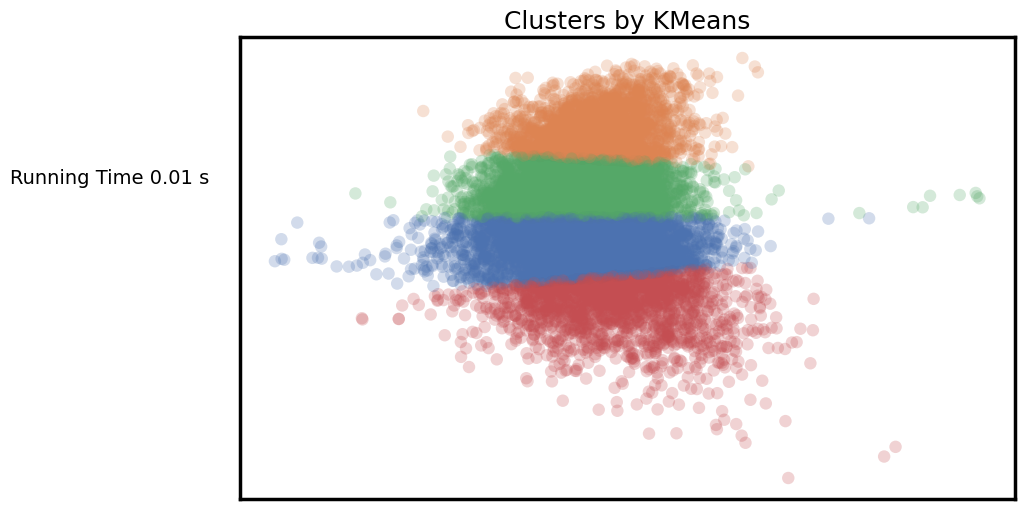


  CLUSTER 0 (Word2Vec)

Palavras semanticamente próximas ao centro do cluster:
Não foi possível extrair palavras similares.

Top-10 Documentos (Amostras):
 - [Doc 0]: From: lerxst@wam.umd.edu (where's my thing) Subject: WHAT car is this!? Nntp-Posting-Host: rac3.wam.umd.edu Organization: University of Maryland, Coll...
 - [Doc 1]: From: guykuo@carson.u.washington.edu (Guy Kuo) Subject: SI Clock Poll - Final Call Summary: Final call for SI clock reports Keywords: SI,acceleration,...
 - [Doc 6]: From: bmdelane@quads.uchicago.edu (brian manning delaney) Subject: Brain Tumor Treatment (thanks) Reply-To: bmdelane@midway.uchicago.edu Organization:...
 - [Doc 7]: From: bgrubb@dante.nmsu.edu (GRUBB) Subject: Re: IDE vs SCSI Organization: New Mexico State University, Las Cruces, NM Lines: 44 Distribution: world N...
 - [Doc 9]: From: kerr@ux1.cso.uiuc.edu (Stan Kerr) Subject: Re: Sigma Designs Double up?? Article-I.D.: ux1.C52u8x.B62 Organization: University of Illinois at Ur...
 - [Doc 10]: F

In [48]:
n_clusters = 4

print("Clusterização usando TF-IDF:")
plt.figure(figsize=(10, 6))
plot_clusters(data_tfidf, cluster.KMeans, (), {'n_clusters': n_clusters}, show_details=True, vector_type='tfidf')

print("\n" + "="*50 + "\n")

print("Clusterização usando Word2Vec:")
plt.figure(figsize=(10, 6))
plot_clusters(data_word2vec, cluster.KMeans, (), {'n_clusters': n_clusters}, show_details=True, vector_type='word2vec')

### 13. Clusterização com Spectral Clustering (TF-IDF vs Word2Vec)

Vamos comparar como os documentos se agrupam usando as duas representações vetoriais diferentes.

Clusterização usando TF-IDF:


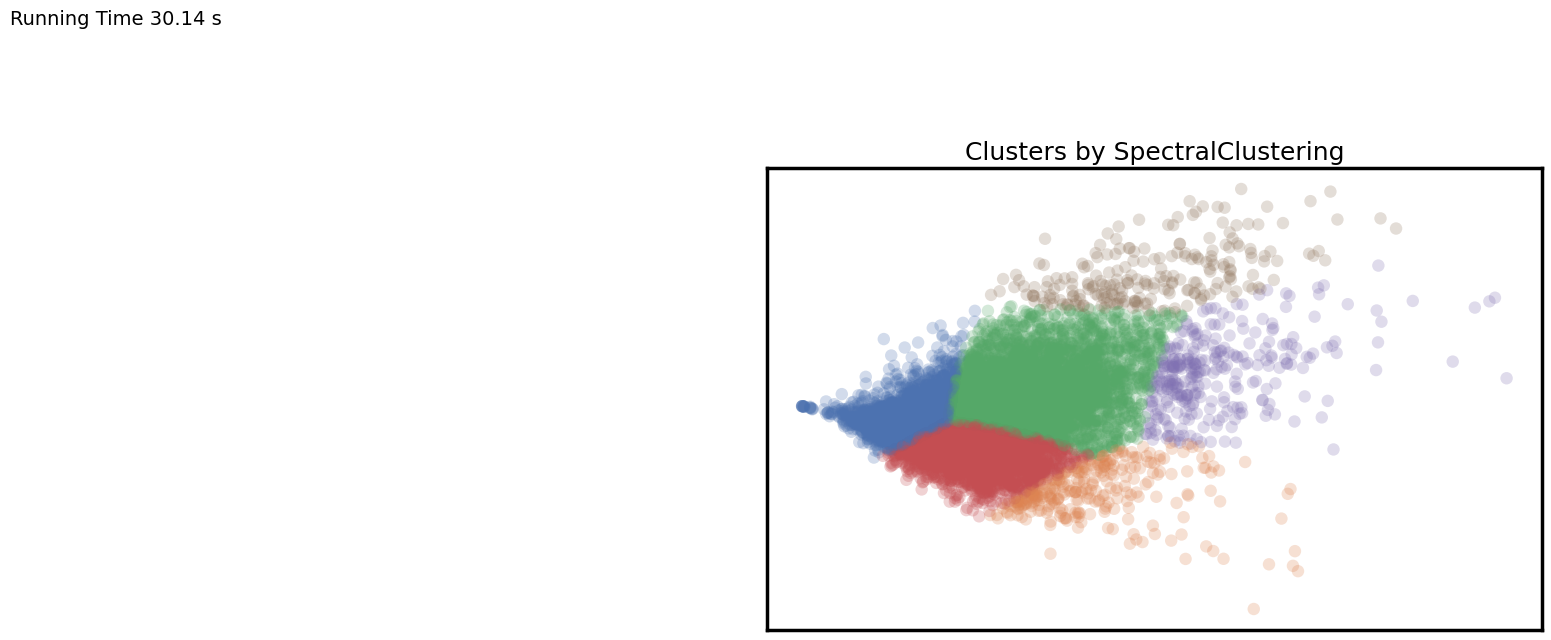


  CLUSTER 0

Top-20 Tokens:
line, subject, organization, university, nntppostinghost, write, article, distribution, replyto, thanks, sale, new, 11, know, anyone, one, 10, usa, email, would

Top-10 Documentos (Amostras):
 - [Doc 12]: From: rodc@fc.hp.com (Rod Cerkoney) Subject: *$G4qxF,fekVH6 Nntp-Posting-Host: hpfcmrc.fc.hp.com Organization: Hewlett Packard, Fort Collins, CO X-New...
 - [Doc 21]: From: leunggm@odin.control.utoronto.ca (Gary Leung) Subject: Re: NHL Team Captains Organization: University of Toronto, Systems Control Group Lines: 2...
 - [Doc 27]: From: r4938585@joplin.biosci.arizona.edu (Doug Roberts) Subject: Re: NL vs. AL? Organization: University of Arizona, Biotechnology, Tucson Lines: 2 NN...
 - [Doc 31]: Subject: Teenage acne From: pchurch@swell.actrix.gen.nz (Pat Churchill) Organization: Actrix Networks Lines: 26   My 14-y-o son has the usual teenage ...
 - [Doc 32]: From: xandor@unixg.ubc.ca (John Gilbert ) Subject: Re: Exploding TV! Organization: The University 

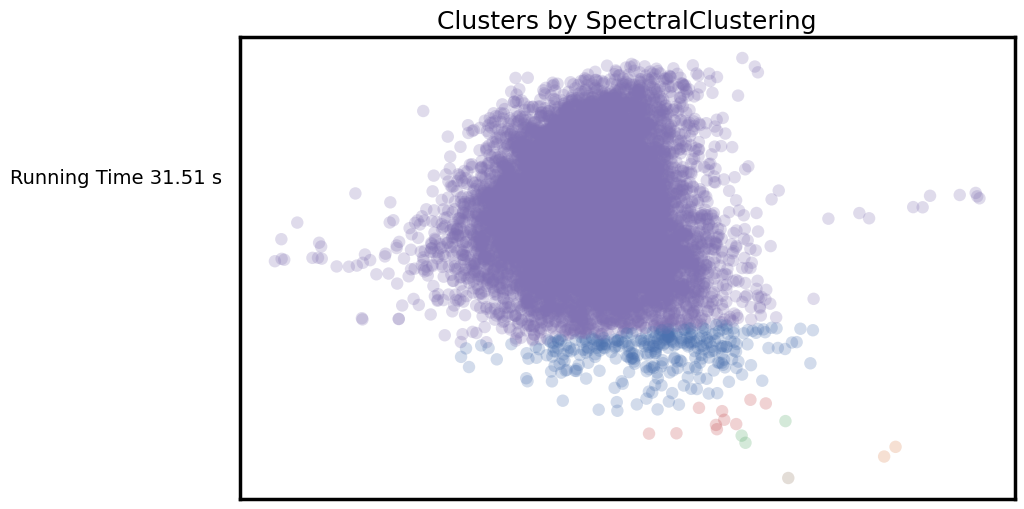


  CLUSTER 0 (Word2Vec)

Palavras semanticamente próximas ao centro do cluster:
Não foi possível extrair palavras similares.

Top-10 Documentos (Amostras):
 - [Doc 12]: From: rodc@fc.hp.com (Rod Cerkoney) Subject: *$G4qxF,fekVH6 Nntp-Posting-Host: hpfcmrc.fc.hp.com Organization: Hewlett Packard, Fort Collins, CO X-New...
 - [Doc 27]: From: r4938585@joplin.biosci.arizona.edu (Doug Roberts) Subject: Re: NL vs. AL? Organization: University of Arizona, Biotechnology, Tucson Lines: 2 NN...
 - [Doc 41]: From: root@ncube.com (Operator) Subject: Re: Which fax modem is the best? Nntp-Posting-Host: admin Reply-To: root@ncube.com Organization: nCUBE Corp.,...
 - [Doc 46]: From: vng@iscs.nus.sg Subject: Wyse 60 Terminal Emulator Reply-To: VNG@ISCS.NUS.SG Organization: Dept of Info Sys and Comp Sci, National University of...
 - [Doc 52]: From: yuting@Xenon.Stanford.EDU (Eugene Y. Kuo) Subject: Any updated Canon BJ-200 driver? Organization: Computer Science Department, Stanford Universi...
 - [Doc 1

In [49]:
# Para clusterizar usando TF-IDF:
n_clusters = 6
print("Clusterização usando TF-IDF:")
plt.figure(figsize=(10, 6))
plot_clusters(data_tfidf, cluster.SpectralClustering, (), {'n_clusters': n_clusters},show_details=True, vector_type='tfidf')
plt.show()

# Para clusterizar usando Word2Vec:
print("\nClusterização usando Word2Vec:")
plt.figure(figsize=(10, 6))
plot_clusters(data_word2vec, cluster.SpectralClustering, (), {'n_clusters': n_clusters},show_details=True, vector_type='word2vec')
plt.show()

### 14. Clusterização com Gaussian Mixture (TF-IDF vs Word2Vec)

Vamos comparar como os documentos se agrupam usando as duas representações vetoriais diferentes.

Clusterização usando TF-IDF:


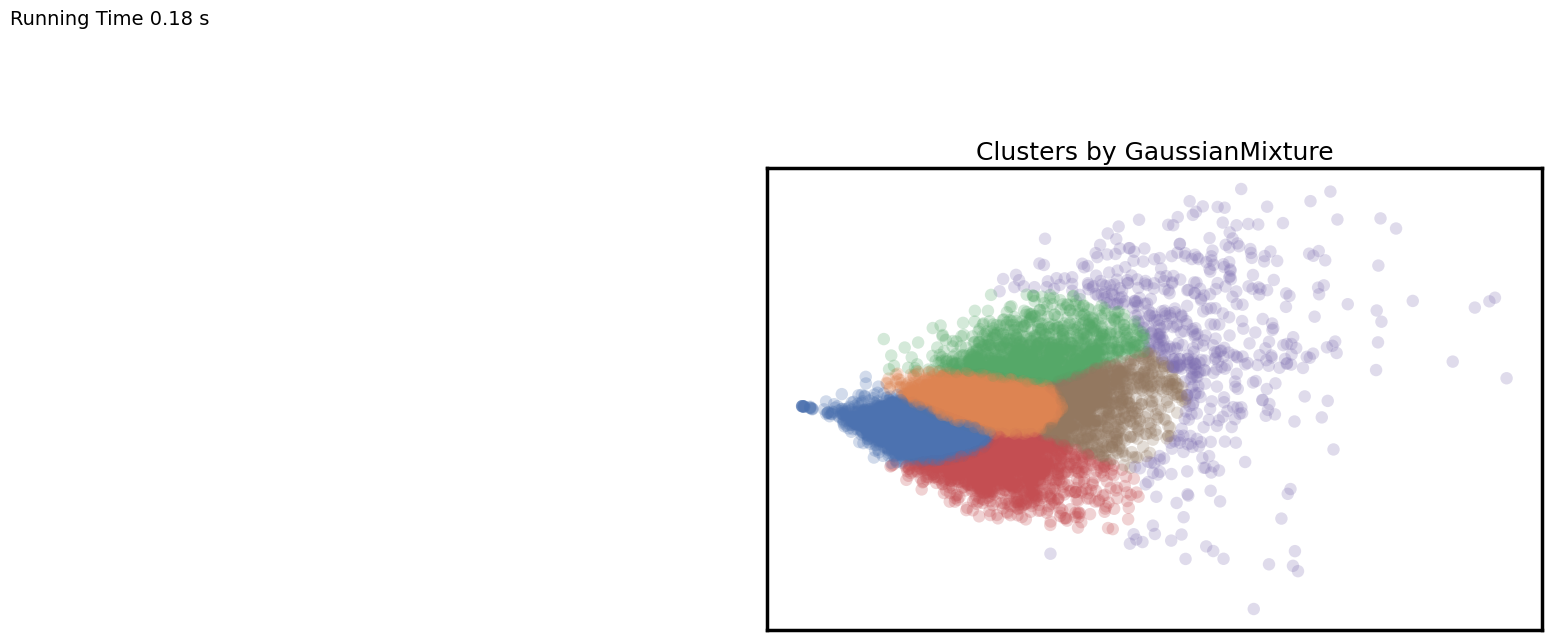


  CLUSTER 0

Top-20 Tokens:
line, subject, organization, university, nntppostinghost, thanks, distribution, use, email, sale, anyone, please, get, usa, write, need, know, replyto, new, look

Top-10 Documentos (Amostras):
 - [Doc 6]: From: bmdelane@quads.uchicago.edu (brian manning delaney) Subject: Brain Tumor Treatment (thanks) Reply-To: bmdelane@midway.uchicago.edu Organization:...
 - [Doc 8]: From: holmes7000@iscsvax.uni.edu Subject: WIn 3.0 ICON HELP PLEASE! Organization: University of Northern Iowa Lines: 10  I have win 3.0 and downloaded...
 - [Doc 10]: From: irwin@cmptrc.lonestar.org (Irwin Arnstein) Subject: Re: Recommendation on Duc Summary: What's it worth? Distribution: usa Expires: Sat, 1 May 19...
 - [Doc 12]: From: rodc@fc.hp.com (Rod Cerkoney) Subject: *$G4qxF,fekVH6 Nntp-Posting-Host: hpfcmrc.fc.hp.com Organization: Hewlett Packard, Fort Collins, CO X-New...
 - [Doc 18]: From: ritley@uimrl7.mrl.uiuc.edu () Subject: SEEKING THERMOCOUPLE AMPLIFIER CIRCUIT Reply-To: ritle

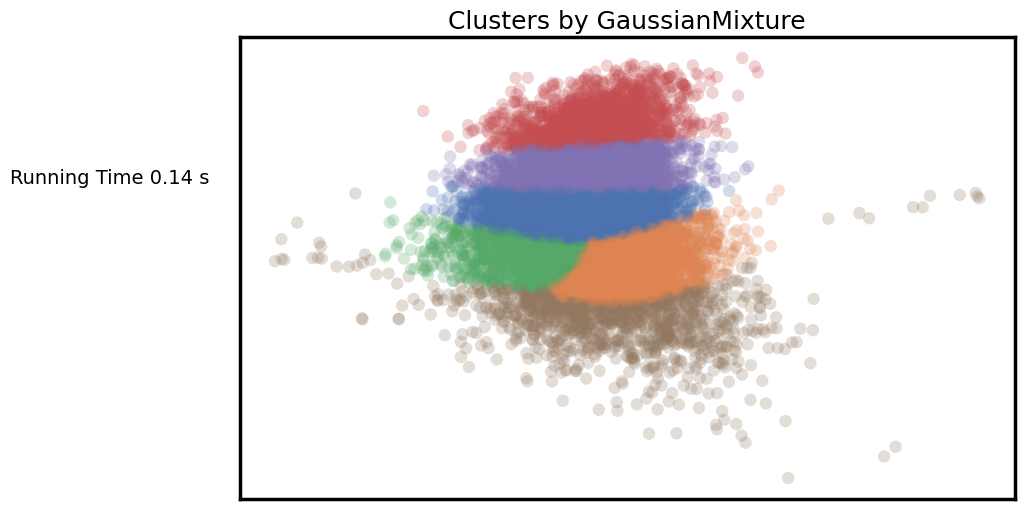


  CLUSTER 0 (Word2Vec)

Palavras semanticamente próximas ao centro do cluster:
Não foi possível extrair palavras similares.

Top-10 Documentos (Amostras):
 - [Doc 2]: From: twillis@ec.ecn.purdue.edu (Thomas E Willis) Subject: PB questions... Organization: Purdue University Engineering Computer Network Distribution: ...
 - [Doc 4]: From: jcm@head-cfa.harvard.edu (Jonathan McDowell) Subject: Re: Shuttle Launch Question Organization: Smithsonian Astrophysical Observatory, Cambridge...
 - [Doc 6]: From: bmdelane@quads.uchicago.edu (brian manning delaney) Subject: Brain Tumor Treatment (thanks) Reply-To: bmdelane@midway.uchicago.edu Organization:...
 - [Doc 13]: From: dbm0000@tm0006.lerc.nasa.gov (David B. Mckissock) Subject: Re: Space Station Redesign, JSC Alternative #4 Organization: NASA Lewis Research Cent...
 - [Doc 16]: From: ab@nova.cc.purdue.edu (Allen B) Subject: Re: TIFF: philosophical significance of 42 Organization: Purdue University Lines: 39  In article <prest...
 - [Doc 18]:

In [50]:
# Para clusterizar usando TF-IDF:
n_clusters = 6
print("Clusterização usando TF-IDF:")
plt.figure(figsize=(10, 6))
plot_clusters(data_tfidf, GMM.GaussianMixture, (), {'n_components': n_clusters},show_details=True, vector_type='tfidf')
plt.show()

# Para clusterizar usando Word2Vec:
print("\nClusterização usando Word2Vec:")
plt.figure(figsize=(10, 6))
plot_clusters(data_word2vec, GMM.GaussianMixture, (), {'n_components': n_clusters},show_details=True, vector_type='word2vec')
plt.show()

### 15. Clusterização com Agglomerative Clustering (TF-IDF vs Word2Vec)

Vamos comparar como os documentos se agrupam usando as duas representações vetoriais diferentes.

Clusterização usando TF-IDF:


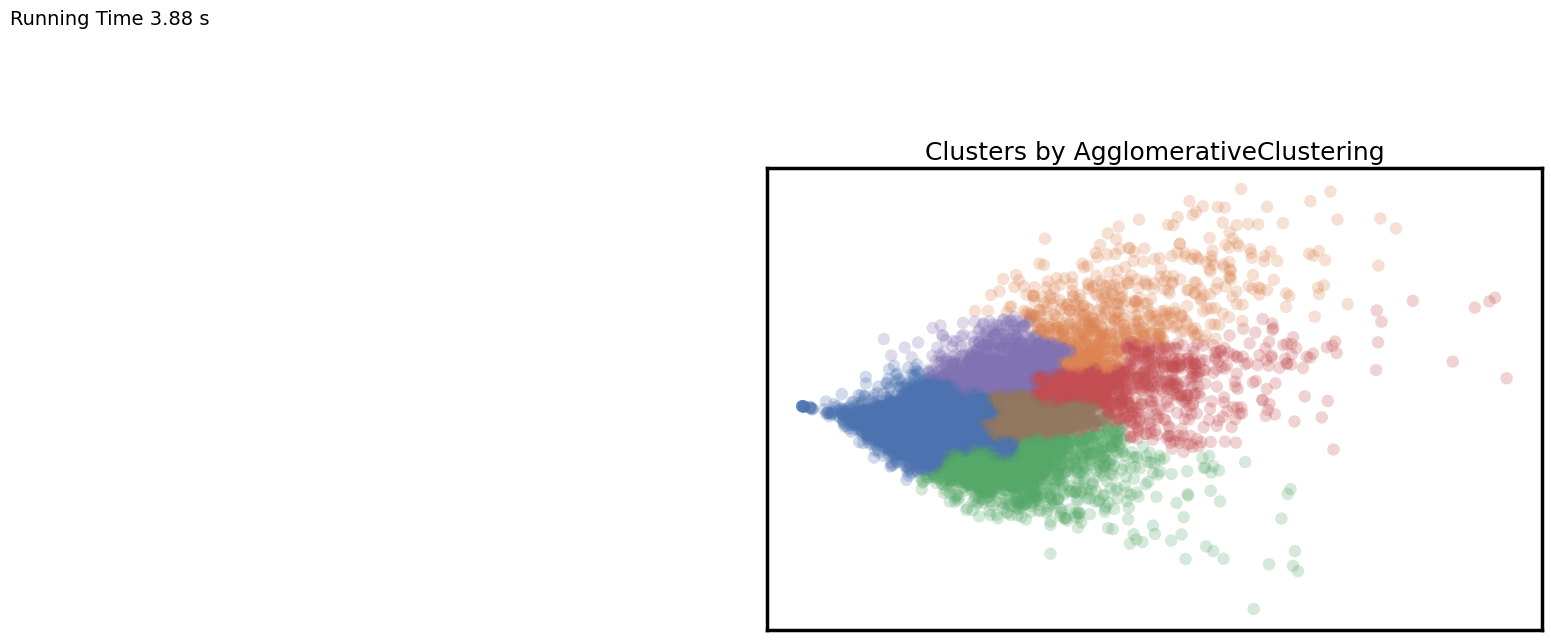


  CLUSTER 0

Top-20 Tokens:
line, subject, organization, university, nntppostinghost, write, article, use, distribution, get, thanks, would, one, know, anyone, new, email, like, replyto, usa

Top-10 Documentos (Amostras):
 - [Doc 6]: From: bmdelane@quads.uchicago.edu (brian manning delaney) Subject: Brain Tumor Treatment (thanks) Reply-To: bmdelane@midway.uchicago.edu Organization:...
 - [Doc 8]: From: holmes7000@iscsvax.uni.edu Subject: WIn 3.0 ICON HELP PLEASE! Organization: University of Northern Iowa Lines: 10  I have win 3.0 and downloaded...
 - [Doc 10]: From: irwin@cmptrc.lonestar.org (Irwin Arnstein) Subject: Re: Recommendation on Duc Summary: What's it worth? Distribution: usa Expires: Sat, 1 May 19...
 - [Doc 12]: From: rodc@fc.hp.com (Rod Cerkoney) Subject: *$G4qxF,fekVH6 Nntp-Posting-Host: hpfcmrc.fc.hp.com Organization: Hewlett Packard, Fort Collins, CO X-New...
 - [Doc 14]: From: jllee@acsu.buffalo.edu (Johnny L Lee) Subject: RE:  == MOVING SALE === Summary: RE:  === MOV

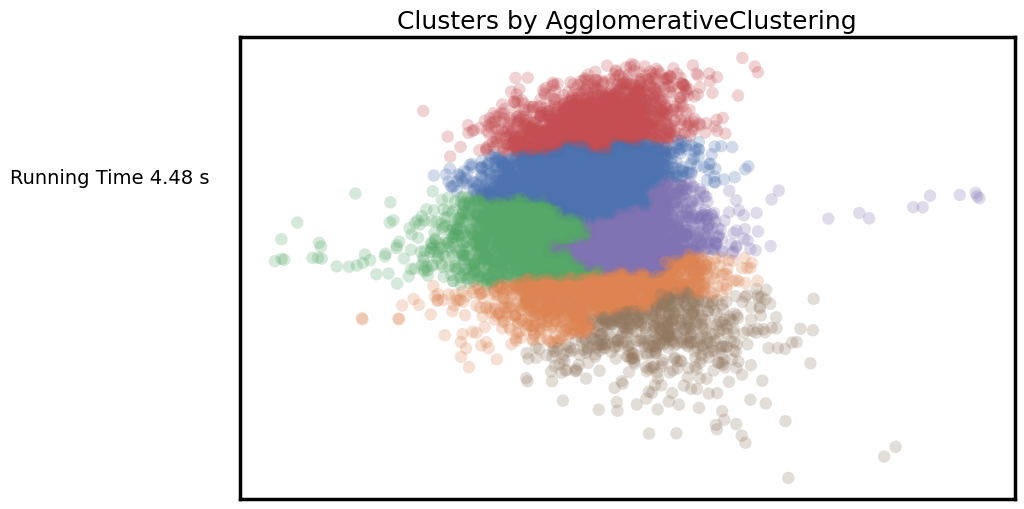


  CLUSTER 0 (Word2Vec)

Palavras semanticamente próximas ao centro do cluster:
Não foi possível extrair palavras similares.

Top-10 Documentos (Amostras):
 - [Doc 16]: From: ab@nova.cc.purdue.edu (Allen B) Subject: Re: TIFF: philosophical significance of 42 Organization: Purdue University Lines: 39  In article <prest...
 - [Doc 17]: From: CPKJP@vm.cc.latech.edu (Kevin Parker) Subject: Insurance Rates on Performance Cars SUMMARY Organization: Louisiana Tech University Lines: 244 NN...
 - [Doc 20]: From: keith@cco.caltech.edu (Keith Allan Schneider) Subject: Re: <<Pompous ass Organization: California Institute of Technology, Pasadena Lines: 16 NN...
 - [Doc 26]: From: nagle@netcom.com (John Nagle) Subject: Re: What do Nuclear Site's Cooling Towers do? Organization: NETCOM On-line Communication Services (408 24...
 - [Doc 29]: From: jimf@centerline.com (Jim Frost) Subject: Re: Is car saftey important? Organization: CenterLine Software, Inc. Lines: 14 NNTP-Posting-Host: 140.2...
 - [Doc 3

In [51]:
# Para clusterizar usando TF-IDF:
n_clusters = 6
print("Clusterização usando TF-IDF:")
plt.figure(figsize=(10, 6))
plot_clusters(data_tfidf, cluster.AgglomerativeClustering, (), {'n_clusters':n_clusters, 'linkage':'ward'},show_details=True, vector_type='tfidf')
plt.show()

# Para clusterizar usando Word2Vec:
print("\nClusterização usando Word2Vec:")
plt.figure(figsize=(10, 6))
plot_clusters(data_word2vec, cluster.AgglomerativeClustering, (), {'n_clusters':n_clusters, 'linkage':'ward'},show_details=True, vector_type='word2vec')
plt.show()

### 16. Clusterização com DBSCAN (TF-IDF vs Word2Vec)

Vamos comparar como os documentos se agrupam usando as duas representações vetoriais diferentes.

Clusterização usando TF-IDF:


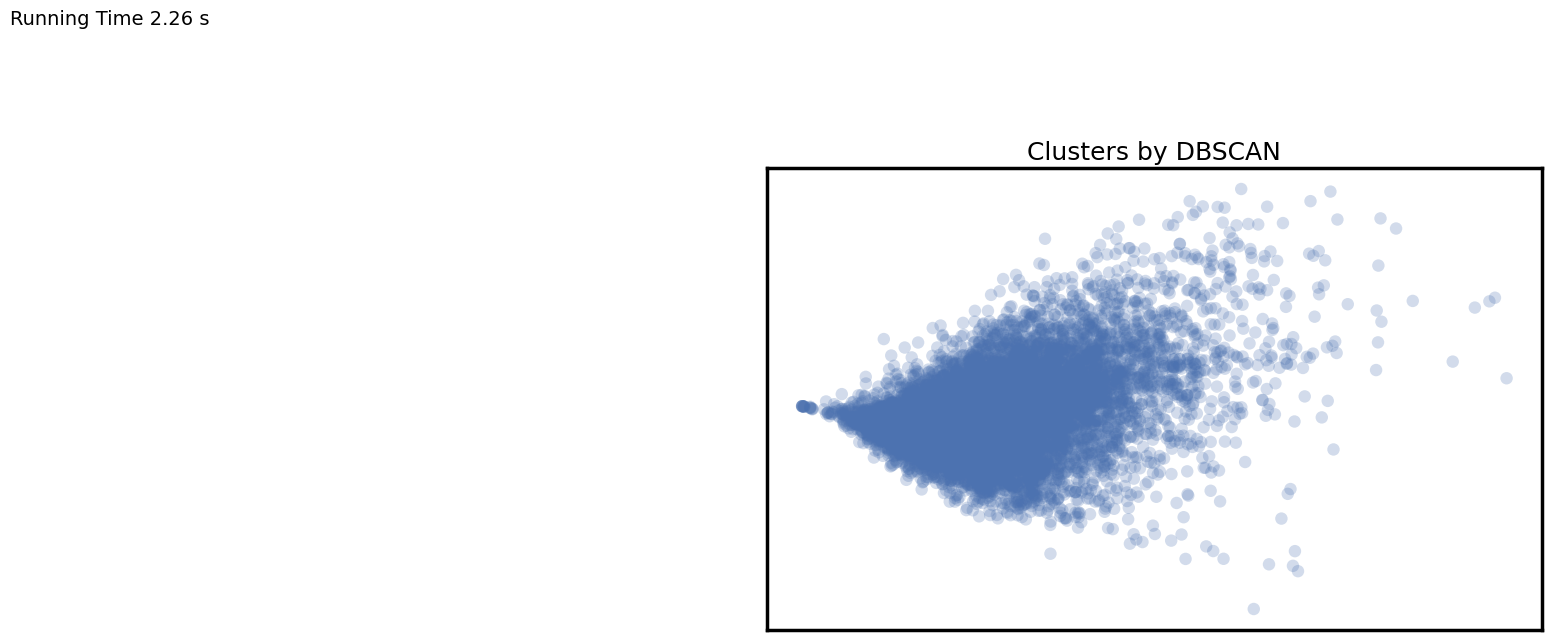


  CLUSTER 0

Top-20 Tokens:
line, would, subject, organization, write, one, get, use, article, university, know, say, nntppostinghost, like, dont, think, go, people, make, good

Top-10 Documentos (Amostras):
 - [Doc 0]: From: lerxst@wam.umd.edu (where's my thing) Subject: WHAT car is this!? Nntp-Posting-Host: rac3.wam.umd.edu Organization: University of Maryland, Coll...
 - [Doc 1]: From: guykuo@carson.u.washington.edu (Guy Kuo) Subject: SI Clock Poll - Final Call Summary: Final call for SI clock reports Keywords: SI,acceleration,...
 - [Doc 2]: From: twillis@ec.ecn.purdue.edu (Thomas E Willis) Subject: PB questions... Organization: Purdue University Engineering Computer Network Distribution: ...
 - [Doc 3]: From: jgreen@amber (Joe Green) Subject: Re: Weitek P9000 ? Organization: Harris Computer Systems Division Lines: 14 Distribution: world NNTP-Posting-H...
 - [Doc 4]: From: jcm@head-cfa.harvard.edu (Jonathan McDowell) Subject: Re: Shuttle Launch Question Organization: Smithsonian A

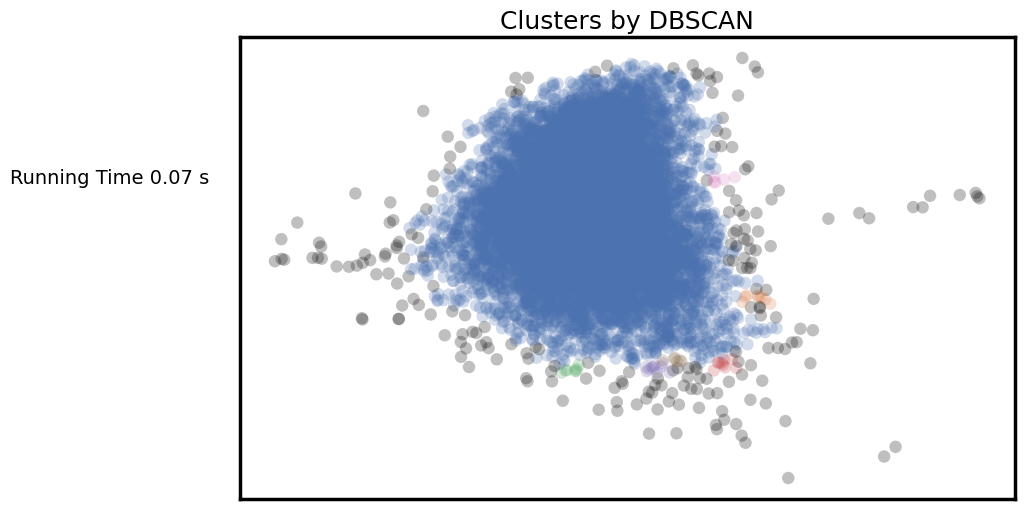


  CLUSTER 0 (Word2Vec)

Palavras semanticamente próximas ao centro do cluster:
Não foi possível extrair palavras similares.

Top-10 Documentos (Amostras):
 - [Doc 0]: From: lerxst@wam.umd.edu (where's my thing) Subject: WHAT car is this!? Nntp-Posting-Host: rac3.wam.umd.edu Organization: University of Maryland, Coll...
 - [Doc 1]: From: guykuo@carson.u.washington.edu (Guy Kuo) Subject: SI Clock Poll - Final Call Summary: Final call for SI clock reports Keywords: SI,acceleration,...
 - [Doc 2]: From: twillis@ec.ecn.purdue.edu (Thomas E Willis) Subject: PB questions... Organization: Purdue University Engineering Computer Network Distribution: ...
 - [Doc 3]: From: jgreen@amber (Joe Green) Subject: Re: Weitek P9000 ? Organization: Harris Computer Systems Division Lines: 14 Distribution: world NNTP-Posting-H...
 - [Doc 4]: From: jcm@head-cfa.harvard.edu (Jonathan McDowell) Subject: Re: Shuttle Launch Question Organization: Smithsonian Astrophysical Observatory, Cambridge...
 - [Doc 5]: Fr

In [52]:
# Para clusterizar usando TF-IDF:
#eps=0.025
eps=0.1
print("Clusterização usando TF-IDF:")
plt.figure(figsize=(10, 6))
plot_clusters(data_tfidf, cluster.DBSCAN, (), {'eps':eps},show_details=True, vector_type='tfidf')
plt.show()

# Para clusterizar usando Word2Vec:
print("\nClusterização usando Word2Vec:")
plt.figure(figsize=(10, 6))
plot_clusters(data_word2vec, cluster.DBSCAN, (), {'eps':eps},show_details=True, vector_type='word2vec')
plt.show()

### 17. Clusterização com HDBSCAN (TF-IDF vs Word2Vec)

Vamos comparar como os documentos se agrupam usando as duas representações vetoriais diferentes.

Clusterização usando TF-IDF:


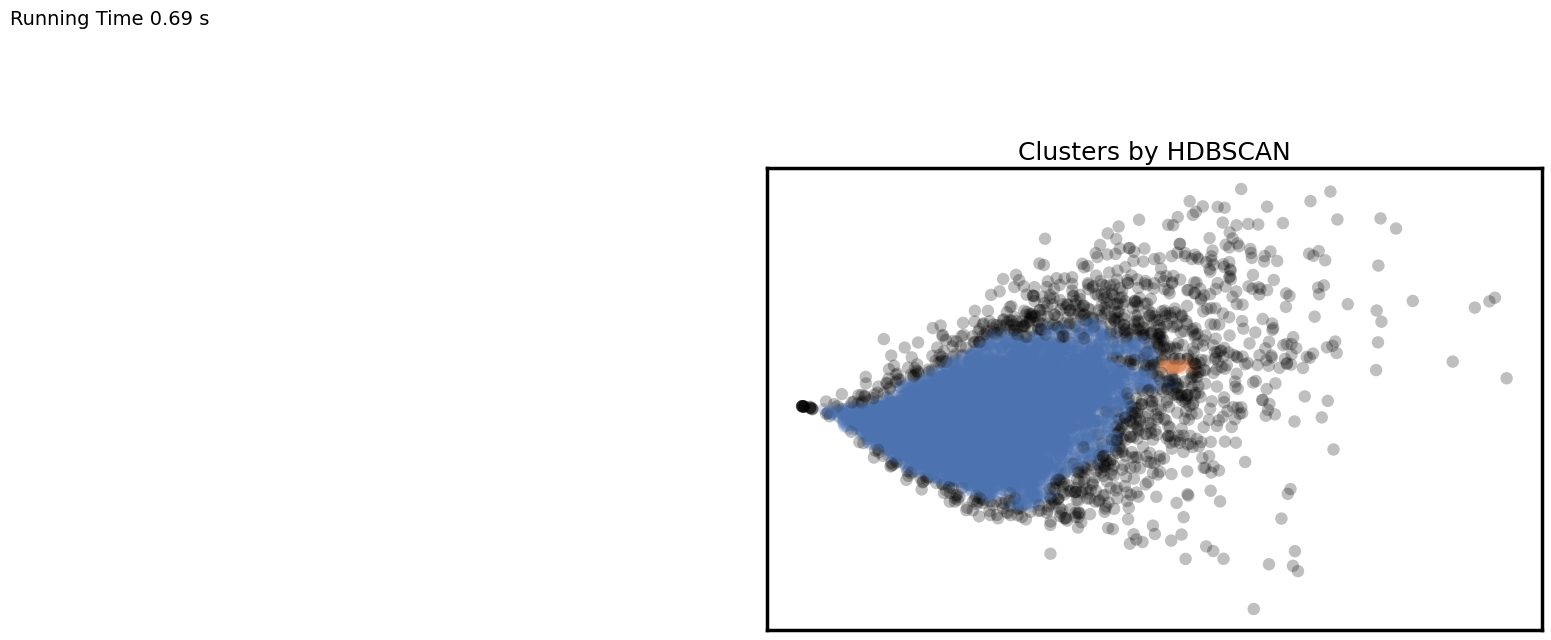


  CLUSTER 0

Top-20 Tokens:
line, subject, organization, write, would, university, article, get, use, one, nntppostinghost, know, like, go, dont, say, think, make, new, im

Top-10 Documentos (Amostras):
 - [Doc 0]: From: lerxst@wam.umd.edu (where's my thing) Subject: WHAT car is this!? Nntp-Posting-Host: rac3.wam.umd.edu Organization: University of Maryland, Coll...
 - [Doc 1]: From: guykuo@carson.u.washington.edu (Guy Kuo) Subject: SI Clock Poll - Final Call Summary: Final call for SI clock reports Keywords: SI,acceleration,...
 - [Doc 3]: From: jgreen@amber (Joe Green) Subject: Re: Weitek P9000 ? Organization: Harris Computer Systems Division Lines: 14 Distribution: world NNTP-Posting-H...
 - [Doc 4]: From: jcm@head-cfa.harvard.edu (Jonathan McDowell) Subject: Re: Shuttle Launch Question Organization: Smithsonian Astrophysical Observatory, Cambridge...
 - [Doc 5]: From: dfo@vttoulu.tko.vtt.fi (Foxvog Douglas) Subject: Re: Rewording the Second Amendment (ideas) Organization: VTT Line

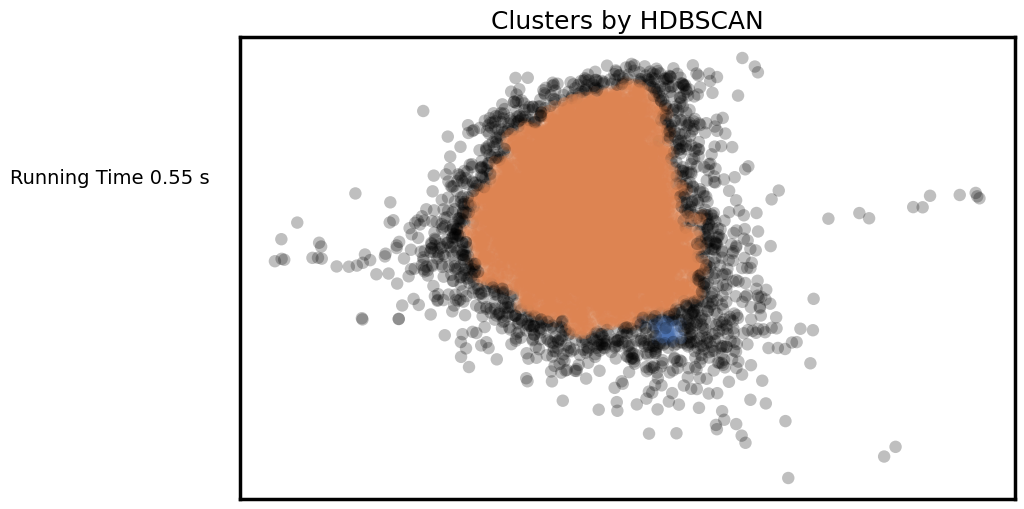


  CLUSTER 0 (Word2Vec)

Palavras semanticamente próximas ao centro do cluster:
Não foi possível extrair palavras similares.

Top-10 Documentos (Amostras):
 - [Doc 138]: From: 2a42dubinski@vms.csd.mu.edu Subject: RE: Can I Change ""Licensed To"" Data in Windows 3.1? Organization: Marquette University - Computer Service...
 - [Doc 338]: Subject: Cubs mailing list From: andrew@dark.side.of.the.moon.uoknor.edu (Chihuahua Charlie) Distribution: usa Organization: OU - Academic User Servic...
 - [Doc 409]: From: edb9140@tamsun.tamu.edu (E.B.) Subject: POV problems with tga outputs Organization: Texas A&M University, College Station, TX Lines: 9 Distribut...
 - [Doc 882]: From: unpingco@raman.ucsd.edu (Jose Unpingco) Subject: FOR SALE: ULTRABOTS PC GAME Keywords: ULTRABOTS,video game, pc game Lines: 6  Electronics Art's...
 - [Doc 1457]: From: hrs1@cbnewsi.cb.att.com (herman.r.silbiger) Subject: ANSI/AIIM MS-53 Standard Image File Format Organization: AT&T Keywords: image, file format ...
 - 

In [54]:
# Para clusterizar usando TF-IDF:
#min_clusters=15
min_clusters=20
print("Clusterização usando TF-IDF:")
plt.figure(figsize=(10, 6))
plot_clusters(data_tfidf, hdbscan.HDBSCAN, (), {'min_cluster_size':min_clusters},show_details=True, vector_type='tfidf')
plt.show()

# Para clusterizar usando Word2Vec:
print("\nClusterização usando Word2Vec:")
plt.figure(figsize=(10, 6))
plot_clusters(data_word2vec, hdbscan.HDBSCAN, (), {'min_cluster_size':min_clusters},show_details=True, vector_type='word2vec')
plt.show()